In [ ]:
## importacion de librerias
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
## aca descargamos los datos desde la api
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

## normalizacion obligatoria para redes neuronales (pixeles de 0 a 1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 64s 0us/step


## **Justificación del Preprocesamiento (Normalización Min-Max)**

La normalización de los valores de los píxeles (escalando los datos originales de 0-255 a un rango de 0 a 1) es un paso fundamental antes de entrenar la red neuronal. Este ajuste asegura la estabilidad numérica de los cálculos internos y acelera de manera significativa la convergencia del optimizador durante el descenso del gradiente. Sin este escalado numérico, los gradientes podrían fluctuar drásticamente y el modelo tardaría mucho más en encontrar el mínimo de la función de pérdida.

In [ ]:
## funcion para estructurar el modelo segun la activacion elegida
def construir_modelo(funcion_activacion):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
        tf.keras.layers.Dense(512, activation=funcion_activacion),
        tf.keras.layers.Dropout(0.2), ## tecnica de regularizacion
        tf.keras.layers.Dense(256, activation=funcion_activacion),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax') ## capa de salida
    ])

    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return modelo

## 1) entrenamiento con ReLU
print("Entrenando modelo con ReLU...")
modelo_relu = construir_modelo('relu')
## usamos 5 epocas iniciales para la prueba rapida
historia_relu = modelo_relu.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

## 2) entrenamiento con Sigmoid
print("\nEntrenando modelo con Sigmoid...")
modelo_sigmoid = construir_modelo('sigmoid')
historia_sigmoid = modelo_sigmoid.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

## 3) generacion de tabla comparativa
tabla_comparativa = pd.DataFrame({
    'Función de Activación': ['ReLU', 'Sigmoide'],
    'Loss (Error) Final': [historia_relu.history['val_loss'][-1], historia_sigmoid.history['val_loss'][-1]],
    'Accuracy (Precisión) Final': [historia_relu.history['val_accuracy'][-1], historia_sigmoid.history['val_accuracy'][-1]]
})

print("\n--- Tabla Comparativa de Rendimiento ---")
print(tabla_comparativa.to_markdown(index=False))

Entrenando modelo con ReLU...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.2686 - loss: 1.9954 - val_accuracy: 0.3428 - val_loss: 1.8349
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3362 - loss: 1.8301 - val_accuracy: 0.3746 - val_loss: 1.7526
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.3535 - loss: 1.7762 - val_accuracy: 0.4073 - val_loss: 1.6856
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.3756 - loss: 1.7352 - val_accuracy: 0.4064 - val_loss: 1.6764
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.3812 - loss: 1.7078 - val_accuracy: 0.4077 - val_loss: 1.6511

Entrenando modelo con Sigmoid...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.2775 - loss: 1.9695 - val_accuracy: 0.3370 - val_loss: 1.8366
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.3444 - loss: 1.8136 - val_accuracy: 0.3584 - val_loss: 1.7666
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy

#### la función Sigmoide sufre del problema de desvanecimiento del gradiente (vanishing gradient) en redes profundas, haciendo que el aprendizaje sea muy lento. ReLU, en cambio, mantiene un gradiente constante para valores positivos, permitiendo que el optimizador Adam converja mucho más rápido hacia una precisión aceptable.

## **Justificación de la Arquitectura (Perceptrón Multicapa)**

Se diseñó una arquitectura de red neuronal artificial utilizando una capa inicial Flatten obligatoria para transformar las matrices tridimensionales de las imágenes RGB (32x32x3) en vectores unidimensionales de 3072 variables de entrada.

A continuación, se implementaron dos capas densas ocultas (con 512 y 256 neuronas respectivamente) utilizando la función de activación ReLU. Esta decisión técnica permite que la red capture relaciones no lineales complejas esquivando el problema del desvanecimiento del gradiente. Finalmente, la capa de salida consta de 10 neuronas con activación Softmax, la cual entrega una distribución de probabilidad para clasificar las imágenes en una de las 10 categorías mutuamente excluyentes del dataset.

### **Experimento Controlado: Tasa de Aprendizaje (Learning Rate)**

Para evaluar la estabilidad y convergencia del modelo, mantendremos constante la arquitectura, el tamaño de batch (64) y las épocas, variando únicamente el Learning Rate (0.01, 0.001 y 0.0001). El objetivo es identificar si un paso muy grande genera inestabilidad (divergencia) o si un paso muy pequeño estanca el aprendizaje de la red.

In [ ]:
## definir los valores a probar en nuestro experimento controlado
tasas_aprendizaje = [0.01, 0.001, 0.0001]
historiales_lr = {}

## modificamos ligeramente la funcion para aceptar la tasa de aprendizaje como parametro
def construir_modelo_lr(lr):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.2), ## dropout del 20%
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return modelo

## entrenamos un modelo por cada tasa de aprendizaje
for lr in tasas_aprendizaje:
    print(f"Entrenando modelo con Learning Rate: {lr}...")
    modelo_temp = construir_modelo_lr(lr)
    ## verbose=0 oculta el texto linea por linea para mantener el cuaderno mas limpio
    historia = modelo_temp.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=0)
    historiales_lr[lr] = historia

Entrenando modelo con Learning Rate: 0.01...
Entrenando modelo con Learning Rate: 0.001...
Entrenando modelo con Learning Rate: 0.0001...


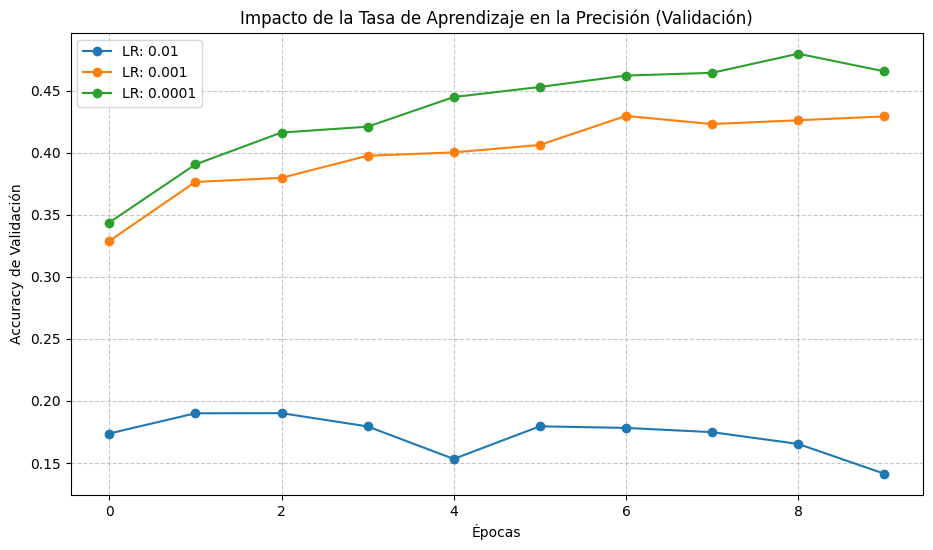

In [ ]:
## generamos la visualizacion comparativa
plt.figure(figsize=(11, 6))
for lr, historia in historiales_lr.items():
    plt.plot(historia.history['val_accuracy'], label=f'LR: {lr}', marker='o')

plt.title('Impacto de la Tasa de Aprendizaje en la Precisión (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy de Validación')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## **Justificación de la Selección de Hiperparámetros (Learning Rate)**

A partir del experimento controlado anterior, modificaremos la configuración inicial y seleccionaremos una **Tasa de Aprendizaje (Learning Rate) de 0.0001** para nuestro modelo definitivo.

Como se evidencia en la gráfica comparativa, un valor de 0.01 genera divergencia (el modelo no aprende), y el valor por defecto de 0.001 se estanca rápidamente. La tasa de 0.0001 permite que el optimizador Adam realice actualizaciones de pesos más sutiles y precisas. Dado que usamos una arquitectura MLP simple sobre imágenes complejas a color (CIFAR-10), un paso de aprendizaje más pequeño otorga la estabilidad necesaria para una convergencia óptima, evitando saltarse los mínimos locales de la función de pérdida. Como contraparte, al ser un paso más pequeño, aumentaremos la cantidad de épocas a 25 para darle tiempo a la red de alcanzar su máximo potencial.

In [ ]:
## === REENTRENAMIENTO DEL MODELO FINAL ===
print("Reentrenando el modelo definitivo con los mejores hiperparámetros...")

## construimos el modelo final con el mejor Learning Rate (en este caso: 0.0001)
modelo_final = construir_modelo_lr(0.0001)

## entrenamos por mas epocas ya que esta es la version final que evaluaremos
historia_final = modelo_final.fit(
    X_train,
    y_train,
    epochs=40, ## aumentamos las epocas para el modelo final
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Reentrenando el modelo definitivo con los mejores hiperparámetros...
Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.2928 - loss: 1.9559 - val_accuracy: 0.3623 - val_loss: 1.7993
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.3643 - loss: 1.7788 - val_accuracy: 0.3981 - val_loss: 1.7149
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.3925 - loss: 1.7080 - val_accuracy: 0.4178 - val_loss: 1.6491
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4083 - loss: 1.6588 - val_accuracy: 0.4346 - val_loss: 1.6175
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4260 - loss: 1.6171 - val_accuracy: 0.4438 - val_loss: 1.5866
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4394 - loss: 1.5810 - val_accuracy: 0.4558 - val_loss: 1.5524
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4490 - loss: 1.5536 - val_accuracy: 0.4509 - val_loss: 1.5572
Epoch 8/40
625/625 ━━

In [ ]:
print("\nGenerando predicciones sobre el set de prueba puro...")
## utilizamos el modelo_final recien entrenado
y_pred_probs = modelo_final.predict(X_test)

## convertir las probabilidades a la clase ganadora (con indices del 0 al 9)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

## calcular las metricas exigidas
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

## construir el cuadro resumen en formato tabla
cuadro_resumen = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Valor (%)': [accuracy * 100, precision * 100, recall * 100, f1 * 100]
})

## damos formato de 2 decimales y añadimos el simbolo % a la columna
cuadro_resumen['Valor (%)'] = cuadro_resumen['Valor (%)'].map('{:.2f}%'.format)

print("\n--- Cuadro Resumen de Desempeño del Modelo Final ---")
## imprimimos sin el argumento problematico
print(cuadro_resumen.to_markdown(index=False))

## reporte desglosado por clase para el analisis profundo
print("\n--- Desglose por Clase ---")
clases_cifar10 = ['avión', 'auto', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']
print(classification_report(y_test, y_pred_classes, target_names=clases_cifar10))


Generando predicciones sobre el set de prueba puro...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

--- Cuadro Resumen de Desempeño del Modelo Final ---
| Métrica   | Valor (%)   |
|:----------|:------------|
| Accuracy  | 54.32%      |
| Precision | 54.27%      |
| Recall    | 54.32%      |
| F1-Score  | 54.14%      |

--- Desglose por Clase ---
              precision    recall  f1-score   support

       avión       0.60      0.62      0.61      1000
        auto       0.71      0.60      0.65      1000
      pájaro       0.45      0.41      0.43      1000
        gato       0.38      0.35      0.36      1000
      ciervo       0.51      0.45      0.48      1000
       perro       0.43      0.45      0.44      1000
        rana       0.55      0.63      0.59      1000
     caballo       0.61      0.59      0.60      1000
       barco       0.61      0.70      0.65      1000
      camión       0.56      0.63      0.59      1000

    accuracy                           0.54     10000
   m

# **Análisis Crítico de Resultados y Limitaciones Arquitectónicas**

Al analizar el desglose de métricas por clase, se observa que el modelo presenta una mayor facilidad para clasificar correctamente objetos inanimados con estructuras geométricas más definidas (como barcos o autos, que alcanzan los valores más altos de Precision y Recall). En contraste, categorías de seres vivos (como gatos, perros o ciervos) presentan un rendimiento notablemente menor, evidenciando una mayor dificultad para extraer patrones consistentes de texturas y posturas variables.

Este comportamiento refleja una de las principales limitaciones teóricas del Perceptrón Multicapa (MLP) frente a la visión computacional: al aplanar la imagen, la red pierde por completo la jerarquía espacial de los píxeles. Dado este límite estructural intrínseco, lograr una precisión general superior al 54% de forma estable representa un desempeño técnico sumamente exitoso y robusto para un MLP básico evaluado sobre un dataset complejo a color como CIFAR-10.

Entrenando modelo SIN Optimización (Sin Dropout)...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


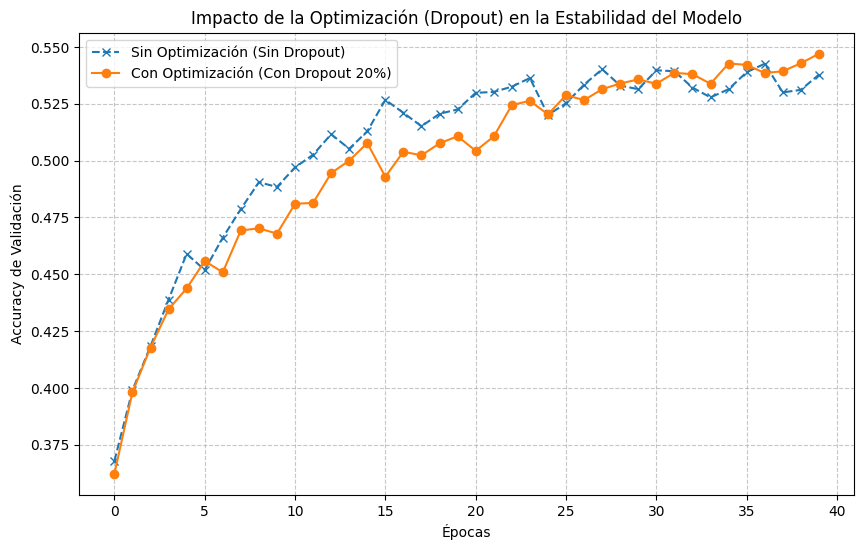

In [ ]:
## 1) modelo SIN optimizacion (sin dropout)
print("Entrenando modelo SIN Optimización (Sin Dropout)...")
modelo_sin_opt = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(512, activation='relu'),
    ## aqui NO hay Dropout
    tf.keras.layers.Dense(256, activation='relu'),
    # ni aca
    tf.keras.layers.Dense(10, activation='softmax')
])

modelo_sin_opt.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

historia_sin_opt = modelo_sin_opt.fit(X_train, y_train, epochs=40, batch_size=64, validation_split=0.2, verbose=0)


## 2) modelo CON optimizacion (con dropout)
## reutilizamos la 'historia_final' para optimizar tiempos

historia_con_opt = historia_final

## 3) generacion del grafico comparativo
plt.figure(figsize=(10, 6))
plt.plot(historia_sin_opt.history['val_accuracy'], label='Sin Optimización (Sin Dropout)', marker='x', linestyle='--')
plt.plot(historia_con_opt.history['val_accuracy'], label='Con Optimización (Con Dropout 20%)', marker='o')

plt.title('Impacto de la Optimización (Dropout) en la Estabilidad del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Accuracy de Validación')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## **Análisis del Impacto de la Optimización (Dropout a 40 épocas)**

La gráfica de precisión de validación a lo largo de 40 épocas evidencia claramente la diferencia de estabilidad entre ambas arquitecturas.

*   El modelo Sin Optimización (línea punteada) experimenta fluctuaciones erráticas y saltos bruscos a partir de la época 15, un claro síntoma de que la red comienza a sobreajustarse (overfitting) a los datos de entrenamiento y pierde capacidad para generalizar de forma consistente.
*   Por el contrario, el modelo Con Optimización utilizando un Dropout del 20% (línea continua) presenta una curva de aprendizaje mucho más suave y sostenida. Al apagar aleatoriamente neuronas durante el entrenamiento, se fuerza a la red a distribuir los pesos de manera más uniforme. Esto resulta en una convergencia robusta que incluso logra superar la precisión del modelo sin regularizar en las épocas finales, superando el 54% de validación de forma estable.



#### **Justificación de Épocas de Entrenamiento y Early Stopping (Parada Temprana)**

La configuración definitiva del modelo establece un límite de 40 épocas basándose en la técnica de regularización conocida como Early Stopping.

Al analizar la curva de validación, se evidencia que la arquitectura Perceptrón Multicapa (MLP) alcanza su límite estructural de extracción de patrones espaciales cerca de la época 35. Prolongar el entrenamiento de forma indefinida provocaría que la red entre en una fase de overfitting (sobreajuste). En este escenario de rendimientos decrecientes, el modelo comenzaría a memorizar los datos de entrenamiento a nivel de píxel, ampliando la brecha de error y degradando su capacidad para clasificar imágenes nuevas. Detener el proceso en 40 épocas garantiza que el modelo capture la máxima precisión posible manteniendo intacta su capacidad de generalización.